## import thư viện

In [ ]:
!pip install transformers==4.57.3 accelerate==1.12.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import json

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset, concatenate_datasets

2026-05-11 15:01:07.025835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778511667.231429      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778511667.290787      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## import dataset VLQA

In [ ]:
with open("/kaggle/input/datasets/huynhdat2010/vlqa-dataset/train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("/kaggle/input/datasets/huynhdat2010/vlqa-dataset/legal_corpus.json", "r", encoding="utf-8") as f:
    legal_corpus = json.load(f)

print("===== TRAIN DATA =====")
print("Số lượng samples:", len(train_data))

print("\n===== LEGAL CORPUS =====")
print("Số lượng law documents:", len(legal_corpus))


===== TRAIN DATA =====
Số lượng samples: 2190

===== LEGAL CORPUS =====
Số lượng law documents: 2157


## cấu trúc lại dataset VLQA

In [ ]:
# TRAIN DATA
train_df = pd.DataFrame(train_data)

# print("\n===== TRAIN HEAD(20) =====")
# display(train_df.head(20))

# In thêm shape cho dễ kiểm tra
print("\n===== SHAPE =====")
print("Train shape:", train_df.shape)


===== SHAPE =====
Train shape: (2190, 4)


In [ ]:
# LEGAL CORPUS
# Flatten để dễ xem
legal_rows = []

for law_doc in legal_corpus:
    doc_id = law_doc["id"]
    law_id = law_doc["law_id"]
    for article in law_doc["content"]:
        legal_rows.append({
            "doc_id": doc_id,
            "law_id": law_id,
            "aid": article["aid"],
            "content_Article": article["content_Article"]
        })

legal_df = pd.DataFrame(legal_rows)

# print("\n===== LEGAL CORPUS HEAD(20) =====")
# display(legal_df.head(20))

print("\n===== SHAPE =====")
print("Legal corpus shape:", legal_df.shape)


===== SHAPE =====
Legal corpus shape: (59636, 4)


In [ ]:
# BUILD LOOKUP TABLES
# aid -> article text
aid_to_article = {}

# aid -> document id
aid_to_docid = {}

# doc_id -> list of articles
docid_to_articles = {}

for _, row in legal_df.iterrows():

    aid = row["aid"]
    article_text = row["content_Article"]
    doc_id = row["doc_id"]

    aid_to_article[aid] = article_text
    aid_to_docid[aid] = doc_id

    if doc_id not in docid_to_articles:
        docid_to_articles[doc_id] = []

    docid_to_articles[doc_id].append({
        "aid": aid,
        "content_Article": article_text
    })

# BUILD RERANKER DATASET
samples = []

for _, row in train_df.iterrows():

    query = row["question"]

    positive_aids = row["relevant_laws"]

    for pos_aid in positive_aids:

        # POSITIVE SAMPLE
        positive_doc = aid_to_article[pos_aid]

        samples.append({
            "query": query,
            "document": positive_doc,
            "label": 1
        })

        # NEGATIVE SAMPLE
        # Random article in the SAME document
        doc_id = aid_to_docid[pos_aid]

        candidate_articles = docid_to_articles[doc_id]

        negative_candidates = [
            article
            for article in candidate_articles
            if article["aid"] != pos_aid
        ]

        # nếu tồn tại negative
        if len(negative_candidates) > 0:

            negative_article = random.choice(negative_candidates)

            samples.append({
                "query": query,
                "document": negative_article["content_Article"],
                "label": 0
            })
# SHUFFLE
# random.shuffle(samples)

# CONVERT TO DATAFRAME
rerank_df = pd.DataFrame(samples)

# CHECK RESULT
print("===== RERANK DATASET =====")
print("Shape:", rerank_df.shape)

print("\n===== HEAD(20) =====")
display(rerank_df.head(20))

print("\n===== LABEL DISTRIBUTION =====")
print(rerank_df["label"].value_counts())

# CONVERT TO HUGGINGFACE DATASET
VLQA_dataset = Dataset.from_pandas(rerank_df)

print("\n===== HF DATASET =====")
display(VLQA_dataset)

===== RERANK DATASET =====
Shape: (5873, 3)

===== HEAD(20) =====


,query,document,label
0,Thưa luật sư tôi có đăng ký kết hôn trên pháp ...,"1. Quan hệ hôn nhân và gia đình được xác lập, ...",1
1,Thưa luật sư tôi có đăng ký kết hôn trên pháp ...,"1. Ở nước Cộng hòa xã hội chủ nghĩa Việt Nam, ...",0
2,Thưa luật sư tôi có đăng ký kết hôn trên pháp ...,"Trong Luật này, các từ ngữ dưới đây được hiểu ...",1
3,Thưa luật sư tôi có đăng ký kết hôn trên pháp ...,"1. Người mang thai hộ, chồng của người mang th...",0
4,Thưa luật sư tôi có đăng ký kết hôn trên pháp ...,1. Quan hệ hôn nhân chấm dứt kể từ ngày bản án...,1
5,Thưa luật sư tôi có đăng ký kết hôn trên pháp ...,1. Việc đại diện giữa vợ và chồng trong việc x...,0
6,Ai có quyền điều hành hoạt động của liên hiệp ...,1. Giám đốc (tổng giám đốc) là người điều hành...,1
7,Ai có quyền điều hành hoạt động của liên hiệp ...,"Luật này áp dụng đối với hợp tác xã, liên hiệp...",0
8,Trình tự đăng ký hành nghề dịch vụ kế toán đượ...,1. Người đăng ký hành nghề dịch vụ kế toán phả...,1
9,Trình tự đăng ký hành nghề dịch vụ kế toán đượ...,Giấy chứng nhận đăng ký hành nghề dịch vụ kế t...,0



===== LABEL DISTRIBUTION =====
label
1    2939
0    2934
Name: count, dtype: int64

===== HF DATASET =====


Dataset({
    features: ['query', 'document', 'label'],
    num_rows: 5873
})

## import dataset ViNLI


In [ ]:
dataset = load_dataset("anti-ai/ViNLI-Zalo-supervised")

README.md:   0%|          | 0.00/133 [00:00<?, ?B/s]

law_vi.jsonl.gz:   0%|          | 0.00/37.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32980 [00:00<?, ? examples/s]

In [ ]:
# print(dataset['train'][0:5])

## cấu trúc lại dataset ViNLI

In [ ]:
def restructure_data(split):
    query_list = dataset[split]["query"]
    positives = dataset[split]["positive"]
    negatives = dataset[split]["hard_neg"]

    samples = []
    for q, pos, neg in zip(query_list, positives, negatives):
        samples.append({"query": q, "document": pos, "label": 1})
        samples.append({"query": q, "document": neg, "label": 0})
    # random.shuffle(samples)
    return Dataset.from_list(samples)

In [ ]:
ViNLI_dataset = restructure_data("train")

In [ ]:
# Kết hợp hai dataset
combined_dataset = concatenate_datasets([VLQA_dataset, ViNLI_dataset])

# Shuffle dữ liệu
train_dataset = combined_dataset.shuffle(seed=42)

# Kiểm tra thông tin
print(f"Kích thước VLQA: {len(VLQA_dataset)}")
print(f"Kích thước ViNLI: {len(ViNLI_dataset)}")
print(f"Kích thước sau khi nối và shuffle: {len(train_dataset)}")

Kích thước VLQA: 5873
Kích thước ViNLI: 65960
Kích thước sau khi nối và shuffle: 71833


## chia train/dev/test

In [ ]:
split = train_dataset.train_test_split(test_size=0.1, seed=42)
temp_train = split["train"]
test_dataset = split["test"]

train_valid = temp_train.train_test_split(test_size=0.1, seed=42)
train_dataset = train_valid["train"]
valid_dataset = train_valid["test"]

In [ ]:
print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 58184
Valid: 6465
Test: 7184


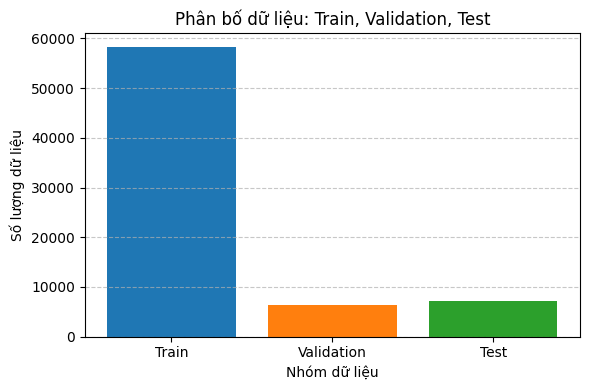

In [ ]:
data_counts = {
    'Train': len(train_dataset),
    'Validation': len(valid_dataset),
    'Test': len(test_dataset)
}

keys = list(data_counts.keys())
values = list(data_counts.values())

cmap = plt.get_cmap('tab10')
colors = cmap(np.arange(len(values)))

plt.figure(figsize=(6, 4))
plt.bar(keys, values, color=colors)
plt.title('Phân bố dữ liệu: Train, Validation, Test')
plt.ylabel('Số lượng dữ liệu')
plt.xlabel('Nhóm dữ liệu')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## tokenizer load

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "Alibaba-NLP/gte-multilingual-reranker-base",
    trust_remote_code=True
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

In [ ]:
def tokenize_fn(examples):
    res = tokenizer(
        examples["query"],
        examples["document"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    res["labels"] = [float(x) for x in examples["label"]]
    return res

In [ ]:
tokenized_train = train_dataset.map(tokenize_fn, batched=True, remove_columns=train_dataset.column_names)
tokenized_valid = valid_dataset.map(tokenize_fn, batched=True, remove_columns=valid_dataset.column_names)
tokenized_test  = test_dataset.map(tokenize_fn, batched=True, remove_columns=test_dataset.column_names)

Map:   0%|          | 0/58184 [00:00<?, ? examples/s]

Map:   0%|          | 0/6465 [00:00<?, ? examples/s]

Map:   0%|          | 0/7184 [00:00<?, ? examples/s]

## model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "Alibaba-NLP/gte-multilingual-reranker-base",
    trust_remote_code=True
)

config.json: 0.00B [00:00, ?B/s]

configuration.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/612M [00:00<?, ?B/s]

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    scores = pred.predictions.squeeze()
    preds = (scores > 0).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/reranker_ckpt",
    overwrite_output_dir=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    num_train_epochs=10,
    weight_decay=0.25,
    fp16=True,
    warmup_ratio=0.1,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none",
    label_names=["labels"],
    remove_unused_columns=False
)

### train

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

/tmp/ipykernel_19/2669883495.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0}.
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.074500,0.014450,0.777881,0.692258,0.999690,0.818044
2,0.011500,0.012730,0.946481,0.903668,0.999381,0.949118
3,0.006500,0.012679,0.965661,0.936937,0.998452,0.966717
4,0.004000,0.013238,0.967208,0.941211,0.996593,0.968111
5,0.002700,0.014039,0.965043,0.937628,0.996284,0.966066
6,0.002100,0.013008,0.976953,0.961908,0.993187,0.977297


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

TrainOutput(global_step=2730, training_loss=0.01689690325286362, metrics={'train_runtime': 28913.3446, 'train_samples_per_second': 20.124, 'train_steps_per_second': 0.157, 'total_flos': 1.2217541527786291e+17, 'train_loss': 0.01689690325286362, 'epoch': 6.0})

### lưu

In [ ]:
model.save_pretrained("/kaggle/working/rerank_model_finetuned_2dataset")
tokenizer.save_pretrained("/kaggle/working/rerank_model_finetuned_2dataset")
print("Model saved!")

Model saved!
